In [2]:
#Sentiment_analysis_ml
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
with zipfile.ZipFile("/content/imdb.zip", "r") as zip_ref:
    zip_ref.extractall("/content")
print(os.listdir("/content"))

['.config', 'imdb.zip', 'IMDB Dataset.csv (1).zip', 'IMDB Dataset.csv', '.ipynb_checkpoints', 'sample_data']


In [4]:
data = pd.read_csv("/content/IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
with open("/content/IMDB Dataset.csv", "rb") as f:
    print(f.read(30))

b'review,sentiment\n"One of the o'


In [6]:
print(data.info())
print(data.head())
print(data['sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
data['sentiment'] = data['sentiment'].map({
    'positive':1,
    'negative':0
}) #Converting sentiment labels into numbers

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]','',text) # Removing punctuation and numbers
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')] # Remove stopwords
    return " ".join(words)
data['clean_review'] = data['review'].apply(clean_text) #Cleaning

In [9]:
Tfidf = TfidfVectorizer(max_features=5000)
X = Tfidf.fit_transform(data['clean_review'])
y = data['sentiment'] #Converting text into numerical features

In [10]:
print(data.head())

                                              review  sentiment  \
0  One of the other reviewers has mentioned that ...          1   
1  A wonderful little production. <br /><br />The...          1   
2  I thought this was a wonderful way to spend ti...          1   
3  Basically there's a family where a little boy ...          0   
4  Petter Mattei's "Love in the Time of Money" is...          1   

                                        clean_review  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


In [11]:
X = data["review"]
y = data["sentiment"]
X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
) #Splitting dataset into training and testing

In [12]:
tfidf = TfidfVectorizer(max_features=5000)# Convert text into numerical values
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [13]:
LR_model = LogisticRegression(max_iter=1000)
LR_model.fit(X_train, y_train)
LR_prediction = LR_model.predict(X_test)

In [14]:
LR_model = LogisticRegression() #Creating Logistic Regression model
LR_model.fit(X_train,y_train) #Train model
LR_prediction = LR_model.predict(X_test)

In [15]:
print("Logistic Regression Accuracy")
print(accuracy_score(y_test,LR_prediction))
print(classification_report(y_test,LR_prediction)) #Evalution

Logistic Regression Accuracy
0.8931
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



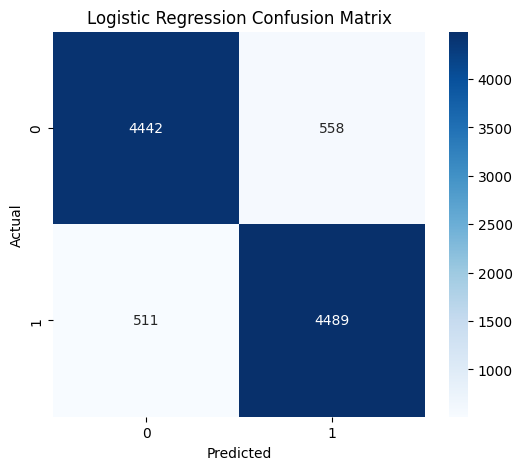

In [16]:
#Ploting confusion matrix
CM = confusion_matrix(y_test,LR_prediction)
plt.figure(figsize=(6,5))
sns.heatmap(CM,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
svm_model = SVC() #Creating SVM model
svm_model.fit(X_train,y_train) # Training  model
svm_prediction = svm_model.predict(X_test)

In [21]:
print("SVM Accuracy")
print(accuracy_score(y_test,svm_prediction))
print(classification_report(y_test,svm_prediction)) # Evaluating

SVM Accuracy
0.8979
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5000
           1       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



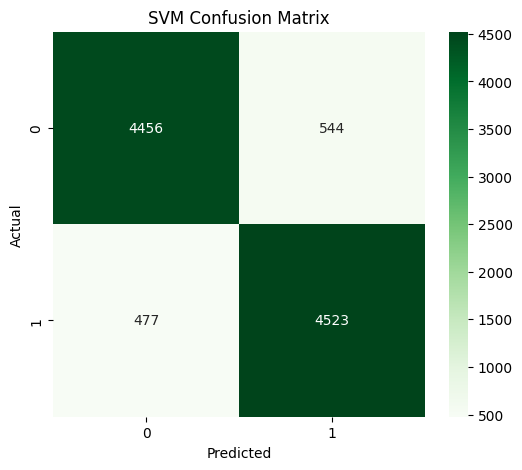

In [22]:
# Ploting confusion matrix
CM = confusion_matrix(y_test,svm_prediction)
plt.figure(figsize=(6,5))
sns.heatmap(CM,
            annot=True,
            fmt='d',
            cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

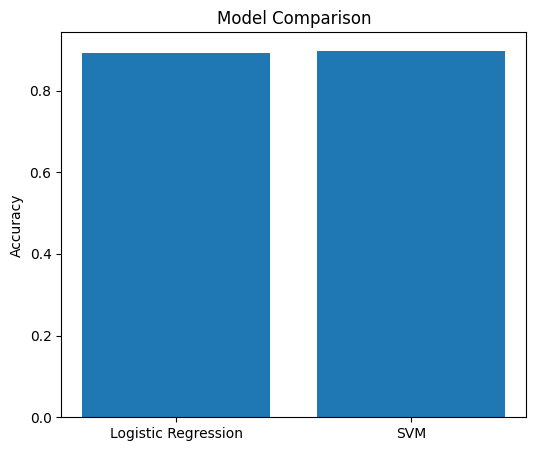

In [23]:
accuracy = [
accuracy_score(y_test,LR_prediction),
accuracy_score(y_test,svm_prediction)
]
models = [
'Logistic Regression',
'SVM'
]
plt.figure(figsize=(6,5))
plt.bar(models,accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show() #Model comparison